In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from PIL import Image
from transformers import DistilBertModel, AutoTokenizer, CLIPVisionModelWithProjection, CLIPProcessor
from peft import PeftModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
import unicodedata

In [ ]:
!pip install --upgrade torchao peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_DIR = '/content/drive/MyDrive/checkpoints/stage2'
CSV_PATH   = '/content/drive/MyDrive/metadata_stage1_ready.xlsx'
IMAGE_ROOT = '/content/drive/MyDrive/캡스톤 디자인 - Team Oasis/images_final'

# ==========================================
# 1. 모델 형태에 맞게 각각 로드하기
# ==========================================
TEXT_MODEL_NAME = 'sentence-transformers/clip-ViT-B-32-multilingual-v1'
VISION_MODEL_NAME = 'openai/clip-vit-base-patch32'

print("⏳ 학습된 가중치를 불러오는 중...")

# 1) Text Encoder: Full Model로 저장되었으므로 일반적인 방식으로 바로 불러옵니다.
text_encoder = DistilBertModel.from_pretrained(os.path.join(SAVE_DIR, "text_lora")).to(device)
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

# 2) Vision Encoder: LoRA로 저장되었으므로 베이스 모델을 부르고 PeftModel로 합칩니다.
base_vision_encoder = CLIPVisionModelWithProjection.from_pretrained(VISION_MODEL_NAME)
vision_encoder = PeftModel.from_pretrained(base_vision_encoder, os.path.join(SAVE_DIR, "vision_lora")).to(device)
processor = CLIPProcessor.from_pretrained(VISION_MODEL_NAME)

print("✅ 두 모델 모두 성공적으로 로드되었습니다!")

⏳ 학습된 가중치를 불러오는 중...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_att

✅ 두 모델 모두 성공적으로 로드되었습니다!



최종 Train: 3834장 / Val: 426장
❌ 누락 파일 발견 (제외됨): 명상정원_7_공공3유형.jpg
❌ 누락 파일 발견 (제외됨): 226_서울역_옥상정원(the_roof)_01.jpg
❌ 누락 파일 발견 (제외됨): 제주동화마을_1_공공3유형.jpg
❌ 누락 파일 발견 (제외됨): 회덕메타세쿼이아길_4_공공3유형.jpg
❌ 누락 파일 발견 (제외됨): 숨도_6_공공3유형.jpg
❌ 누락 파일 발견 (제외됨): 고살리_숲길_1_공공3유형.jpg
❌ 누락 파일 발견 (제외됨): [충주_풍경길]_종댕이길_1_공공1유형.jpg
🔎 이미지 폴더 스캔 중...
✅ 총 4846개의 실제 파일 인식 완료.
✅ Stage 2 모델 로드 완료! 평가를 시작합니다.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



🏆 [Stage 2 정량적 평가 결과]
1. Validation Loss: 3.5110
2. Scene Classification Acc: 74.46%
3. Silhouette Score: 0.0713 (클수록 군집화 우수)

🔎 검색어: '눈 내린 고즈넉한 사찰 풍경'


/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight

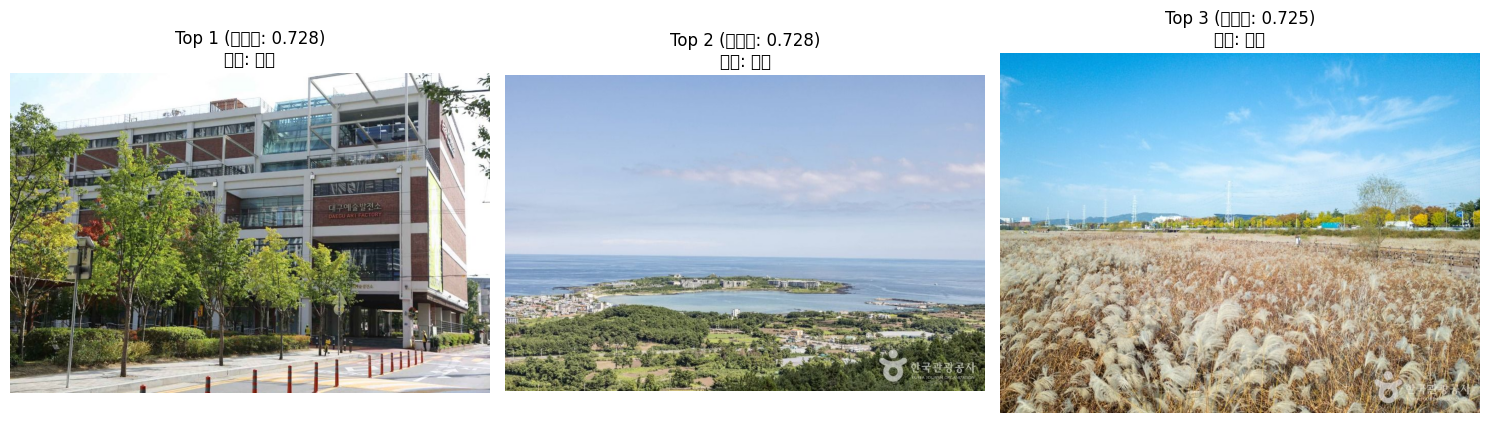


🔎 검색어: '파도 소리가 들리는 청량한 바다'


/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12794/220928007.py:231: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3

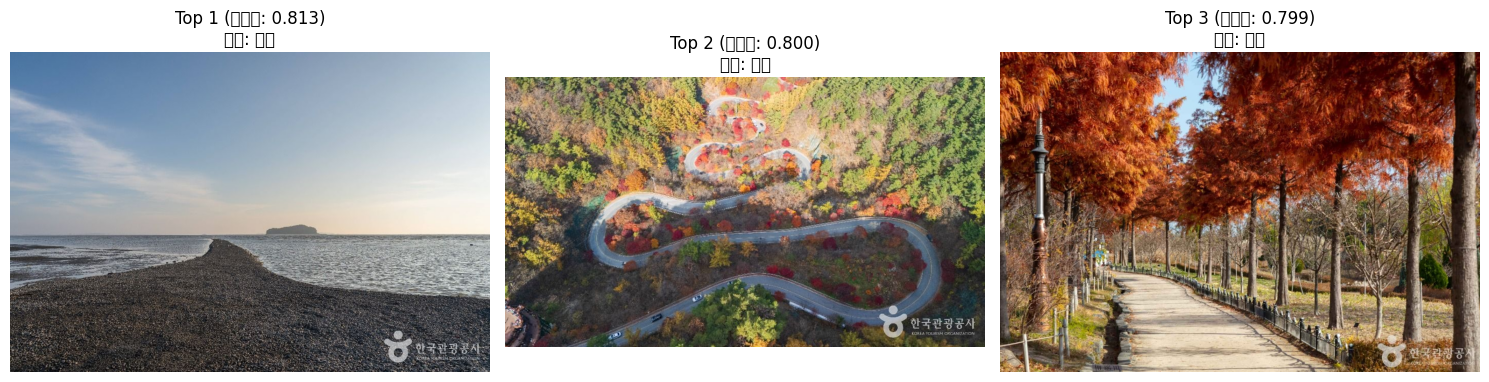

In [ ]:
class TravelDataset(Dataset):
    def __init__(self, df, image_root, processor, tokenizer, scene2idx):
        self.df         = df.reset_index(drop=True)
        self.image_root = image_root
        self.processor  = processor
        self.tokenizer  = tokenizer
        self.scene2idx  = scene2idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. 엑셀에 적힌 이미지 아이디 정규화
        target_id = dn(row['image_id'])

        # 2. 매핑 테이블에서 실제 파일명 찾기
        real_file_name = actual_file_map.get(target_id)

        if real_file_name is None:
            # 파일이 없을 경우 에러 메시지를 명확히 출력
            raise FileNotFoundError(f"❌ 파일 없음: {target_id} (엑셀 행 번호: {idx})")

        img_path = os.path.join(self.image_root, real_file_name)

        # 이미지 로드 및 처리
        try:
            image = Image.open(img_path).convert('RGB')
            pixel_values = self.processor(images=image, return_tensors='pt')['pixel_values'].squeeze(0)
        except Exception as e:
            print(f"❌ 이미지 로드 실패: {img_path}")
            raise e

        # 텍스트 처리
        enc = self.tokenizer(
            str(row['caption']),
            padding='max_length', max_length=64,
            truncation=True, return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        # scene 라벨
        scene_label = self.scene2idx.get(str(row['scene']), 0)

        return pixel_values, input_ids, attention_mask, scene_label

# --- 데이터 로드 및 분할 ---
df = pd.read_excel(CSV_PATH)

# scene 라벨 (13개)
SCENE_CLASSES = ['바다','산','숲','도시','호수','거리','전통','공원','전망','조형물','카페','온천','전시']
SCENE2IDX     = {s: i for i, s in enumerate(SCENE_CLASSES)}
NUM_CLASSES   = len(SCENE_CLASSES)

# 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR         = 1e-3
LAMBDA_CE  = 0.7

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
print(f'\n최종 Train: {len(train_df)}장 / Val: {len(val_df)}장')

safe_rows = []
for idx, row in val_df.iterrows():
    real_file_name = dn(row['image_id'])
    img_path = os.path.join(IMAGE_ROOT, real_file_name)

    # 파일이 진짜로 폴더에 있으면 리스트에 추가
    if os.path.exists(img_path):
        safe_rows.append(row)
    else:
        print(f"❌ 누락 파일 발견 (제외됨): {real_file_name}")

# 안전한 데이터만 모아서 새로운 DataFrame 생성
val_df_safe = pd.DataFrame(safe_rows).reset_index(drop=True)

# 데이터로더 생성
val_dataset   = TravelDataset(val_df_safe,   IMAGE_ROOT, processor, text_tokenizer, SCENE2IDX)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ---  한글 인코딩 문제 해결을 위한 정규화 함수 ---
def dn(text):
    if pd.isna(text): return ""
    return unicodedata.normalize('NFC', str(text)).strip()

# --- 실제 폴더 안의 파일들을 미리 스캔 (딱 한 번만 실행) ---
# 엑셀의 이름과 실제 파일명이 인코딩 차이로 다를 때를 대비해 매핑 테이블을 만듭니다.
print("🔎 이미지 폴더 스캔 중...")
actual_file_map = {dn(f): f for f in os.listdir(IMAGE_ROOT) if not f.startswith('.')}
print(f"✅ 총 {len(actual_file_map)}개의 실제 파일 인식 완료.")

# ==========================================
# 2. Custom Heads 정의 및 가중치 로드
# ==========================================
class ProjectionHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class SceneHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(512, 256),   # net.0
            nn.ReLU(),             # net.1 (가중치 없음)
            nn.Dropout(0.3),       # net.2 (가중치 없음)
            nn.Linear(256, 13)     # net.3
        )
    def forward(self, x):
        return self.net(x)

txt_proj_layer = nn.Linear(768, 512).to(device)
proj_head = ProjectionHead().to(device)
scene_head = SceneHead().to(device)

# 저장된 헤드 가중치 불러오기
heads_state = torch.load(os.path.join(SAVE_DIR, "custom_heads.pt"), map_location=device)
txt_proj_layer.load_state_dict(heads_state['txt_proj_layer'])
proj_head.load_state_dict(heads_state['proj_head'])
scene_head.load_state_dict(heads_state['scene_head'])

print("✅ Stage 2 모델 로드 완료! 평가를 시작합니다.")

# ==========================================
# 3. 정량적 평가 (Val Loss, Acc, Silhouette Score)
# ==========================================
text_encoder.eval(); vision_encoder.eval()
txt_proj_layer.eval(); proj_head.eval(); scene_head.eval()

val_loss = 0.0
correct_scene = 0
total_samples = 0

all_img_embeddings = []
all_scene_labels = []

# (주의: val_loader가 메모리에 정의되어 있어야 합니다)
with torch.no_grad():
    for batch in val_loader:
        pixel_values, input_ids, attention_mask, scene_labels = [b.to(device) for b in batch]

        # 특징 추출
        img_feat = vision_encoder(pixel_values=pixel_values).image_embeds
        txt_out = text_encoder(input_ids=input_ids, attention_mask=attention_mask)[0][:, 0, :]
        txt_feat = txt_proj_layer(txt_out)

        # 256차원 투영
        i_emb = proj_head(img_feat)
        t_emb = proj_head(txt_feat)

        # Loss 계산
        logits = i_emb @ t_emb.T * torch.exp(torch.tensor(0.07).to(device))
        targets = torch.arange(pixel_values.size(0)).to(device)
        loss_clip = (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2

        scene_logits = scene_head(img_feat)
        loss_ce = F.cross_entropy(scene_logits, scene_labels)

        loss = loss_clip + loss_ce
        val_loss += loss.item()

        # Accuracy 계산
        preds = torch.argmax(scene_logits, dim=1)
        correct_scene += (preds == scene_labels).sum().item()
        total_samples += scene_labels.size(0)

        # Silhouette Score를 위한 수집
        all_img_embeddings.append(i_emb.cpu().numpy())
        all_scene_labels.append(scene_labels.cpu().numpy())

avg_val_loss = val_loss / len(val_loader)
scene_acc = (correct_scene / total_samples) * 100

all_img_embeddings = np.concatenate(all_img_embeddings, axis=0)
all_scene_labels = np.concatenate(all_scene_labels, axis=0)

sil_score = silhouette_score(all_img_embeddings, all_scene_labels, metric='cosine')

print("\n" + "="*40)
print("🏆 [Stage 2 정량적 평가 결과]")
print(f"1. Validation Loss: {avg_val_loss:.4f}")
print(f"2. Scene Classification Acc: {scene_acc:.2f}%")
print(f"3. Silhouette Score: {sil_score:.4f} (클수록 군집화 우수)")
print("="*40)

# ==========================================
# 4. 정성적 평가 (Qualitative Test) - 시각화
# ==========================================

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'


def qualitative_test(query_text, top_k=3):
    print(f"\n🔎 검색어: '{query_text}'")
    with torch.no_grad():
        enc = text_tokenizer(query_text, return_tensors='pt', padding=True, truncation=True)
        txt_out = text_encoder(input_ids=enc['input_ids'].to(device),
                               attention_mask=enc['attention_mask'].to(device))[0][:, 0, :]
        txt_feat = txt_proj_layer(txt_out)
        t_emb = proj_head(txt_feat)

        similarities = (all_img_embeddings @ t_emb.cpu().numpy().T).squeeze()
        top_indices = similarities.argsort()[-top_k:][::-1]

    fig, axes = plt.subplots(1, top_k, figsize=(5 * top_k, 5))
    if top_k == 1: axes = [axes]

    for i, idx in enumerate(top_indices):
        # val_df가 정의되어 있고, 'image_id'와 'scene' 컬럼이 있다고 가정
        row = val_df.iloc[idx]
        img_path = os.path.join(IMAGE_ROOT, row['image_id'])

        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"Top {i+1} (유사도: {similarities[idx]:.3f})\n분류: {row.get('scene', 'N/A')}", fontsize=12)
            axes[i].axis('off')
        except Exception as e:
            axes[i].set_title("이미지 로드 실패")
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 정성 평가 실행 예시
qualitative_test("눈 내린 고즈넉한 사찰 풍경", top_k=3)
qualitative_test("파도 소리가 들리는 청량한 바다", top_k=3)